## Metric Meaning (Quick)

- **Accuracy**: overall fraction of correct predictions.
- **Macro-F1**: average F1 across classes, each class gets equal weight.
  This is important when you want fair performance across all activities.
- **Weighted-F1**: class-wise F1 weighted by number of samples in each class.

So when you saw:
- Accuracy = 0.8750
- Macro-F1 = 0.8730
- Weighted-F1 = 0.8730

it means the model is both accurate overall and fairly balanced across classes.

# Single Activity Classification from Range-Doppler CSV

This notebook is for **Single Activity Data** under `Research Data/Single Activity Data` only.

Workflow:
1. Load and inspect data dimensionality by activity and sample.
2. Create a **sample-level split**: 60% train (3 samples) and 40% test (2 samples) per activity.
3. Build and train two models for activity recognition:
   - **CNN** (spatial model on aggregated range-doppler map)
   - **LSTM** (temporal model on frame sequence)
4. Show results:
   - loss/accuracy curves
   - confusion matrix
   - classification report

Notes:
- The feature design is inspired by common mmWave micro-Doppler / range-Doppler processing pipelines.
- If TensorFlow is missing, install it in your environment before training.

In [27]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import zoom

from sklearn.metrics import confusion_matrix, classification_report

# Try TensorFlow/Keras for CNN + LSTM
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
except Exception as e:
    raise ImportError(
        "TensorFlow is required. Install with: pip install tensorflow\n"
        f"Original import error: {e}"
    )

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

DATA_ROOT = Path.cwd() / "Research Data" / "Single Activity Data"
EXPECTED_ACTIVITIES = ["Sitting", "Standing", "Waiving", "Walking"]

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_ROOT}")

print("Using data root:", DATA_ROOT)

Using data root: c:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Research Data\Single Activity Data


In [28]:
REQ = ["frame_number", "range_bin", "doppler_bin", "signal_strength"]


def read_longform(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    if all(c in df.columns for c in REQ):
        out = df[REQ].copy()
    else:
        raw = pd.read_csv(csv_path, header=None)
        if raw.shape[1] >= 5:
            raw = raw.iloc[:, :5].copy()
            raw.columns = ["timestamp", *REQ]
        elif raw.shape[1] == 4:
            raw.columns = REQ
        else:
            raise ValueError(f"Unsupported format: {csv_path}")
        out = raw[REQ].copy()

    out[REQ] = out[REQ].apply(pd.to_numeric, errors="coerce")
    out = out.dropna(subset=REQ)
    out["frame_number"] = out["frame_number"].astype(np.int64)
    out["range_bin"] = out["range_bin"].astype(np.int64)
    out["doppler_bin"] = out["doppler_bin"].astype(np.int64)
    out["signal_strength"] = out["signal_strength"].astype(np.float32)
    return out


def dataframe_to_cube(df: pd.DataFrame) -> np.ndarray:
    max_r = int(df["range_bin"].max())
    max_d = int(df["doppler_bin"].max())
    r_bins, d_bins = max_r + 1, max_d + 1

    frames = []
    for _, g in df.groupby("frame_number", sort=True):
        m = np.zeros((r_bins, d_bins), dtype=np.float32)
        r = g["range_bin"].to_numpy(dtype=np.int32)
        d = g["doppler_bin"].to_numpy(dtype=np.int32)
        s = g["signal_strength"].to_numpy(dtype=np.float32)
        m[r, d] = s
        frames.append(m)

    return np.stack(frames, axis=0) if frames else np.empty((0, r_bins, d_bins), dtype=np.float32)


def parse_distance(sample_name: str) -> tuple[str, float]:
    # Handles names like 1m, 2m, 2.5, 4.m
    s = sample_name.strip().lower().replace(" ", "")
    cleaned = s.replace("m", "")
    cleaned = cleaned.replace("..", ".")
    if cleaned.endswith("."):
        cleaned = cleaned[:-1]
    try:
        val = float(cleaned)
        return f"{val:g}m", val
    except Exception:
        return sample_name, np.nan


def scan_single_activity_data(root: Path, expected_activities: list[str]) -> pd.DataFrame:
    rows = []
    for activity in expected_activities:
        act_dir = root / activity
        if not act_dir.exists():
            print(f"Warning: activity folder missing: {act_dir}")
            continue

        sample_dirs = sorted([d for d in act_dir.iterdir() if d.is_dir()])
        sample_dirs = [d for d in sample_dirs if (d / "range_doppler.csv").exists()]

        if len(sample_dirs) < 5:
            print(f"Warning: {activity} has {len(sample_dirs)} samples with range_doppler.csv (expected 5)")

        for sample_dir in sample_dirs[:5]:
            csv_path = sample_dir / "range_doppler.csv"
            df = read_longform(csv_path)
            distance_label, distance_m = parse_distance(sample_dir.name)
            rows.append(
                {
                    "activity": activity,
                    "distance": distance_label,
                    "distance_m": distance_m,
                    "sample_name": sample_dir.name,
                    "csv_path": csv_path,
                    "rd_points": len(df),
                    "n_frames": int(df["frame_number"].nunique()),
                }
            )

    meta = pd.DataFrame(rows)
    if meta.empty:
        raise RuntimeError("No valid samples found in Single Activity Data")

    return meta.sort_values(["activity", "distance_m", "sample_name"], na_position="last").reset_index(drop=True)


def split_by_sample(meta: pd.DataFrame) -> pd.DataFrame:
    split_meta = meta.copy()
    split_meta["split"] = ""

    for activity, g in split_meta.groupby("activity"):
        g_sorted = g.sort_values(["distance_m", "sample_name"], na_position="last")
        # 3 train (60%), 2 test (40%) for 5 samples
        train_idx = g_sorted.index[:3]
        test_idx = g_sorted.index[3:5]
        split_meta.loc[train_idx, "split"] = "train"
        split_meta.loc[test_idx, "split"] = "test"

    if (split_meta["split"] == "").any():
        raise RuntimeError("Split assignment failed for some samples")

    return split_meta


meta = scan_single_activity_data(DATA_ROOT, EXPECTED_ACTIVITIES)
split_meta = split_by_sample(meta)

# User-facing dimensionality table with requested columns
class_to_id = {a: i for i, a in enumerate(EXPECTED_ACTIVITIES)}
split_meta_view = split_meta.copy()
split_meta_view["target_class_id"] = split_meta_view["activity"].map(class_to_id)
split_meta_view = split_meta_view.rename(
    columns={
        "activity": "Activity",
        "distance": "Distance",
        "n_frames": "Frames",
        "rd_points": "RD_Points",
        "split": "Split",
        "target_class_id": "Target_Class_ID",
    }
)

split_meta_view = split_meta_view[[
    "Activity",
    "Distance",
    "Frames",
    "RD_Points",
    "Split",
    "Target_Class_ID",
]]

display(split_meta_view)
print("\nSamples per activity and split:")
print(split_meta.groupby(["activity", "split"]).size().unstack(fill_value=0))

,Activity,Distance,Frames,RD_Points,Split,Target_Class_ID
0,Sitting,1m,46,376832,train,0
1,Sitting,2m,47,385024,train,0
2,Sitting,2.5m,46,376832,train,0
3,Sitting,3m,51,417792,test,0
4,Sitting,4m,50,409600,test,0
5,Standing,1m,52,425984,train,1
6,Standing,2m,58,475136,train,1
7,Standing,2.5m,52,425984,train,1
8,Standing,3m,53,434176,test,1
9,Standing,4m,55,450560,test,1



Samples per activity and split:
split     test  train
activity             
Sitting      2      3
Standing     2      3
Waiving      2      3
Walking      2      3


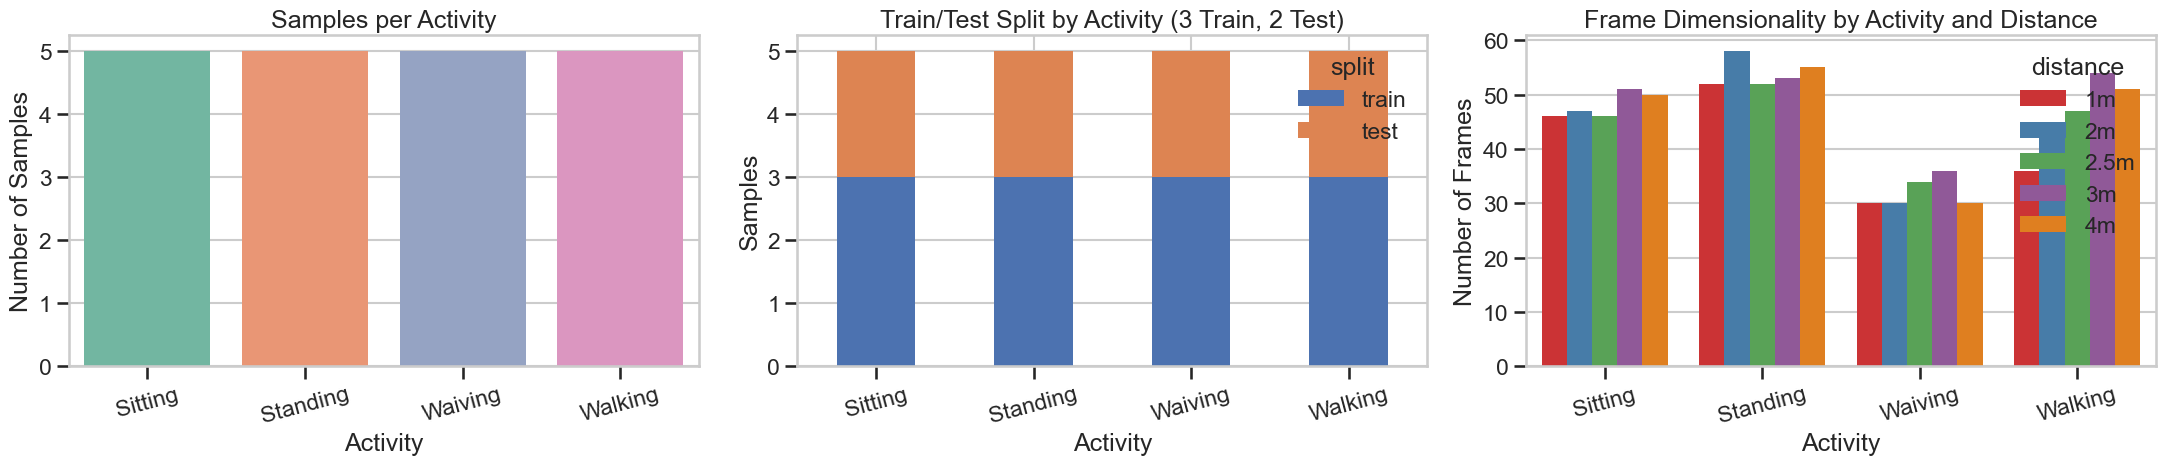

Dimensionality table (requested columns):


,Activity,Distance,Frames,RD_Points,Split,Target_Class_ID
0,Sitting,1m,46,376832,train,0
1,Sitting,2m,47,385024,train,0
2,Sitting,2.5m,46,376832,train,0
3,Sitting,3m,51,417792,test,0
4,Sitting,4m,50,409600,test,0
5,Standing,1m,52,425984,train,1
6,Standing,2m,58,475136,train,1
7,Standing,2.5m,52,425984,train,1
8,Standing,3m,53,434176,test,1
9,Standing,4m,55,450560,test,1



Numeric summary for activity recognition:


,count,mean,std,min,25%,50%,75%,max
Frames,20.0,45.05,9.121836,30.0,36.0,47.0,52.0,58.0
RD_Points,20.0,369049.60,74726.081736,245760.0,294912.0,385024.0,425984.0,475136.0


In [29]:
# Dimensionality and split visualization (before training)
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# 1) Number of samples per activity
sample_counts = split_meta.groupby("activity").size().reindex(EXPECTED_ACTIVITIES)
sns.barplot(x=sample_counts.index, y=sample_counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Samples per Activity")
axes[0].set_xlabel("Activity")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=15)

# 2) Split distribution: train/test per activity
split_counts = split_meta.groupby(["activity", "split"]).size().unstack(fill_value=0).reindex(EXPECTED_ACTIVITIES)
split_counts[["train", "test"]].plot(kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Train/Test Split by Activity (3 Train, 2 Test)")
axes[1].set_xlabel("Activity")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=15)

# 3) Frames by activity and distance
tmp = split_meta.copy()
tmp["distance"] = pd.Categorical(tmp["distance"], categories=sorted(tmp["distance"].unique(), key=lambda x: float(str(x).replace('m','')) if str(x).replace('m','').replace('.','',1).isdigit() else 999), ordered=True)
sns.barplot(data=tmp, x="activity", y="n_frames", hue="distance", ax=axes[2], palette="Set1")
axes[2].set_title("Frame Dimensionality by Activity and Distance")
axes[2].set_xlabel("Activity")
axes[2].set_ylabel("Number of Frames")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print("Dimensionality table (requested columns):")
display(split_meta_view)

print("\nNumeric summary for activity recognition:")
summary = split_meta_view[["Frames", "RD_Points"]].describe().T
display(summary)

In [30]:
# Build tensors from playback-style filtered spectrograms
SPATIAL_SIZE = (64, 64)   # CNN image size for spectrogram
SEQ_LEN = 64              # LSTM temporal length
WINDOW_LEN = 32           # Time window per training example
WINDOWS_PER_SAMPLE = 4
PLAYBACK_MIN = 2048.0
PLAYBACK_MAX = 4096.0

label_to_idx = {a: i for i, a in enumerate(EXPECTED_ACTIVITIES)}
idx_to_label = {i: a for a, i in label_to_idx.items()}


def robust_abs_z(values: np.ndarray) -> np.ndarray:
    med = np.median(values)
    mad = np.median(np.abs(values - med))
    if mad < 1e-9:
        return np.zeros_like(values)
    return np.abs((values - med) / (1.4826 * mad))


def filter_anomalous_cube(cube: np.ndarray) -> np.ndarray:
    # Same idea used in playback: remove clearly corrupted frames only.
    if cube.shape[0] < 5:
        return cube

    means = cube.mean(axis=(1, 2))
    stds = cube.std(axis=(1, 2))
    peaks = cube.max(axis=(1, 2))
    sat_counts = (cube > 60000).sum(axis=(1, 2))

    z_mean = robust_abs_z(means)
    z_std = robust_abs_z(stds)
    z_peak = robust_abs_z(peaks)

    bad = (
        (sat_counts > 0)
        | (peaks > 10000)
        | (stds > 2000)
        | ((z_peak > 12.0) & (z_std > 12.0) & (z_mean > 12.0))
    )

    kept = cube[~bad]
    return kept if len(kept) > 0 else cube


def resize_2d(arr2d: np.ndarray, out_hw=(64, 64)) -> np.ndarray:
    zh = out_hw[0] / arr2d.shape[0]
    zw = out_hw[1] / arr2d.shape[1]
    return zoom(arr2d, (zh, zw), order=1)


def playback_like_process_frame(frame: np.ndarray, out_hw=(64, 64)) -> np.ndarray:
    # Playback-inspired processing for each range-doppler frame.
    shifted = np.fft.fftshift(frame, axes=1)
    rd = resize_2d(shifted, out_hw=out_hw)
    denom = max(PLAYBACK_MAX - PLAYBACK_MIN, 1e-9)
    norm = (rd - PLAYBACK_MIN) / denom
    return np.clip(norm, 0.0, 1.0).astype(np.float32)


def fix_sequence_len(seq: np.ndarray, seq_len: int) -> np.ndarray:
    n = seq.shape[0]
    if n == seq_len:
        return seq
    if n > seq_len:
        idx = np.linspace(0, n - 1, seq_len).astype(int)
        return seq[idx]
    pad_count = seq_len - n
    pad = np.repeat(seq[-1:, ...], pad_count, axis=0)
    return np.concatenate([seq, pad], axis=0)


def make_windows(seq: np.ndarray, win_len: int, n_windows: int) -> np.ndarray:
    # seq shape: [T, D] for spectrogram time slices
    t = seq.shape[0]
    if t <= win_len:
        one = fix_sequence_len(seq, win_len)
        return np.repeat(one[None, ...], n_windows, axis=0)

    starts = np.linspace(0, t - win_len, n_windows).astype(int)
    windows = [seq[s:s + win_len] for s in starts]
    return np.stack(windows, axis=0)


def normalize_spectrogram(spec: np.ndarray) -> np.ndarray:
    # spec: [T, D]
    # Remove static clutter per Doppler bin, then log compression.
    bg = np.median(spec, axis=0, keepdims=True)
    spec = np.clip(spec - bg, 0, None)
    spec = np.log1p(spec)
    lo, hi = np.percentile(spec, [1, 99])
    if hi - lo < 1e-9:
        return np.zeros_like(spec, dtype=np.float32)
    return np.clip((spec - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)


cnn_x, lstm_x, y = [], [], []
sample_trace = []

for _, row in split_meta.iterrows():
    df = read_longform(Path(row["csv_path"]))
    cube = dataframe_to_cube(df)  # [T, R, D]

    # 1) Remove anomalous frames (playback-style robustness)
    cube = filter_anomalous_cube(cube)

    # 2) Process each frame with playback-like normalization
    rd_frames = np.stack([playback_like_process_frame(f, out_hw=SPATIAL_SIZE) for f in cube], axis=0)  # [T, H, W]

    # 3) Build micro-Doppler-like spectrogram: sum over range -> [T, Doppler]
    # Here Doppler axis corresponds to W after FFT shift.
    spec_td = rd_frames.sum(axis=1)  # [T, W]
    spec_td = normalize_spectrogram(spec_td)

    # 4) Uniform temporal length, then windowing
    spec_td = fix_sequence_len(spec_td, SEQ_LEN)                 # [64, 64]
    windows = make_windows(spec_td, WINDOW_LEN, WINDOWS_PER_SAMPLE)  # [Nw, 32, 64]

    for w in windows:
        # CNN uses a resized 2D spectrogram image.
        cnn_img = resize_2d(w, out_hw=SPATIAL_SIZE)[..., None]  # [64, 64, 1]

        # LSTM uses time-major sequence with Doppler features.
        lstm_seq = w  # [32, 64]

        cnn_x.append(cnn_img.astype(np.float32))
        lstm_x.append(lstm_seq.astype(np.float32))
        y.append(label_to_idx[row["activity"]])
        sample_trace.append(row["split"])

cnn_x = np.array(cnn_x, dtype=np.float32)
lstm_x = np.array(lstm_x, dtype=np.float32)
y = np.array(y, dtype=np.int32)
sample_trace = np.array(sample_trace)

is_train = (sample_trace == "train")
is_test = (sample_trace == "test")

x_train_cnn, x_test_cnn = cnn_x[is_train], cnn_x[is_test]
x_train_lstm, x_test_lstm = lstm_x[is_train], lstm_x[is_test]
y_train, y_test = y[is_train], y[is_test]

print("CNN train shape:", x_train_cnn.shape, "test:", x_test_cnn.shape)
print("LSTM train shape:", x_train_lstm.shape, "test:", x_test_lstm.shape)
print("y train/test:", y_train.shape, y_test.shape)

print("\nClass balance (train):")
print(pd.Series(y_train).map(idx_to_label).value_counts())
print("\nClass balance (test):")
print(pd.Series(y_test).map(idx_to_label).value_counts())

CNN train shape: (48, 64, 64, 1) test: (32, 64, 64, 1)
LSTM train shape: (48, 32, 64) test: (32, 32, 64)
y train/test: (48,) (32,)

Class balance (train):
Sitting     12
Standing    12
Waiving     12
Walking     12
Name: count, dtype: int64

Class balance (test):
Sitting     8
Standing    8
Waiving     8
Walking     8
Name: count, dtype: int64


### Technical Summary: Data, Processing, Modeling, and Results

#### 1) What data is used
This notebook uses single-activity radar range-Doppler recordings from `Research Data/Single Activity Data` with four classes: **Sitting, Standing, Waiving, Walking**. For each activity, five sample folders are scanned (each containing `range_doppler.csv`). The split is defined at the **sample level**: 3 samples/activity for training and 2 samples/activity for testing (total 12 train samples, 8 test samples).

#### 2) Data preparation
The preprocessing pipeline is designed to convert raw point-like range-Doppler measurements into stable learning features:

1. Read and standardize CSV schema into four fields: `frame_number`, `range_bin`, `doppler_bin`, `signal_strength`.
2. Convert each sample into a frame cube of shape `[T, R, D]` by placing signal strength into corresponding range and Doppler bins per frame.
3. Apply anomaly filtering per frame using robust statistics and hard thresholds (saturation count, peak intensity, frame standard deviation, and robust z-score checks).
4. Apply playback-consistent frame processing: Doppler-axis FFT shift, resize to `64 x 64`, and normalize intensities with fixed bounds (`PLAYBACK_MIN=2048`, `PLAYBACK_MAX=4096`).
5. Build a time-Doppler representation by summing over range for each frame (`[T, W]`).
6. Apply temporal-spectral normalization: static-background suppression (median subtraction), log compression, and percentile scaling (1st to 99th percentile).
7. Standardize temporal length to `SEQ_LEN=64`.
8. Segment each standardized sample into `WINDOWS_PER_SAMPLE=4` windows of length `WINDOW_LEN=32`.
9. Construct model-specific inputs from each window:
   - CNN input: resized 2D map `64 x 64 x 1`.
   - LSTM input: sequence `32 x 64`.

Because each original sample is split into 4 windows, evaluation is performed on **window-level instances**. Therefore, test size becomes `8 samples x 4 windows = 32` windows.

#### 3) Model preparation
Two baseline classifiers are trained:

- **CNN_Baseline**: Conv2D(16->32->64) with pooling, global average pooling, dropout, dense layer, and softmax output.
- **LSTM_Baseline**: LSTM(64, return sequences) -> dropout -> LSTM(32) -> dense -> softmax.

Training setup is identical for fair comparison:

- Loss: sparse categorical cross-entropy
- Optimizer: Adam (`1e-3`)
- Epoch budget: up to 80
- Batch size: 8
- Early stopping on validation loss (patience 12)
- ReduceLROnPlateau (factor 0.5, patience 6)
- Class weights computed from training labels to reduce class-imbalance bias

#### 4) Results and how to interpret them
From the confusion matrices shown in this notebook (window-level test set, total = 32):

- **CNN_Baseline** confusion matrix diagonal = `2 + 8 + 8 + 8 = 26` correct
  - Window-level accuracy = `26/32 = 0.8125`
  - Performance is very strong for **Standing, Waiving, Walking** (all 8/8), while **Sitting** is partially confused with Standing (6 windows).

- **LSTM_Baseline** confusion matrix diagonal = `5 + 4 + 5 + 8 = 22` correct
  - Window-level accuracy = `22/32 = 0.6875`
  - The model shows notable confusion among **Sitting, Standing, and Waiving**, while **Walking** remains robust (8/8).

The learning curves also support this interpretation: the CNN shows better validation stability and higher final validation accuracy than the LSTM. The LSTM exhibits a larger train-validation gap, indicating weaker generalization under the current data size and feature representation.

#### 5) Overall conclusion
For this dataset and preprocessing design, the **CNN baseline is the stronger model**. The main remaining challenge is separating **Sitting vs Standing** windows, which likely share similar low-motion Doppler signatures. Further improvement would typically come from sample-level decision fusion, larger subject diversity, or richer temporal feature engineering.

In [31]:
from sklearn.utils.class_weight import compute_class_weight


def build_cnn_baseline(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])


def build_lstm_baseline(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(32),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])


def train_model(model, x_train, y_train, x_val, y_val, epochs=80, batch_size=8):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
    ]

    classes = np.unique(y_train)
    cls_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight = {int(c): float(w) for c, w in zip(classes, cls_weights)}

    hist = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks,
        class_weight=class_weight,
    )
    return hist


n_classes = len(EXPECTED_ACTIVITIES)

ablation_models = {
    "CNN": build_cnn_baseline(x_train_cnn.shape[1:], n_classes),
    "LSTM": build_lstm_baseline(x_train_lstm.shape[1:], n_classes),
}

ablation_histories = {}
for name, model in ablation_models.items():
    print(f"\n=== Training {name} ===")
    if name == "CNN":
        hist = train_model(model, x_train_cnn, y_train, x_test_cnn, y_test, epochs=80, batch_size=8)
    else:
        hist = train_model(model, x_train_lstm, y_train, x_test_lstm, y_test, epochs=80, batch_size=8)
    ablation_histories[name] = hist

# Keep compatibility with previous variable names
cnn_model = ablation_models["CNN"]
lstm_model = ablation_models["LSTM"]
cnn_history = ablation_histories["CNN"]
lstm_history = ablation_histories["LSTM"]


=== Training CNN ===
Epoch 1/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.2685 - loss: 1.3889 - val_accuracy: 0.3125 - val_loss: 1.3866 - learning_rate: 0.0010
Epoch 2/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2202 - loss: 1.3857 - val_accuracy: 0.2500 - val_loss: 1.3844 - learning_rate: 0.0010
Epoch 3/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2286 - loss: 1.3853 - val_accuracy: 0.2500 - val_loss: 1.3835 - learning_rate: 0.0010
Epoch 4/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2964 - loss: 1.3822 - val_accuracy: 0.2500 - val_loss: 1.3823 - learning_rate: 0.0010
Epoch 5/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3613 - loss: 1.3801 - val_accuracy: 0.3750 - val_loss: 1.3797 - learning_rate: 0.0010
Epoch 6/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3199 - loss: 1.3765 - val_accuracy: 0.2500 - val_loss: 1.3767 - learning_rate: 0.0010
Epoch 7/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3411 - loss: 1.3733 -

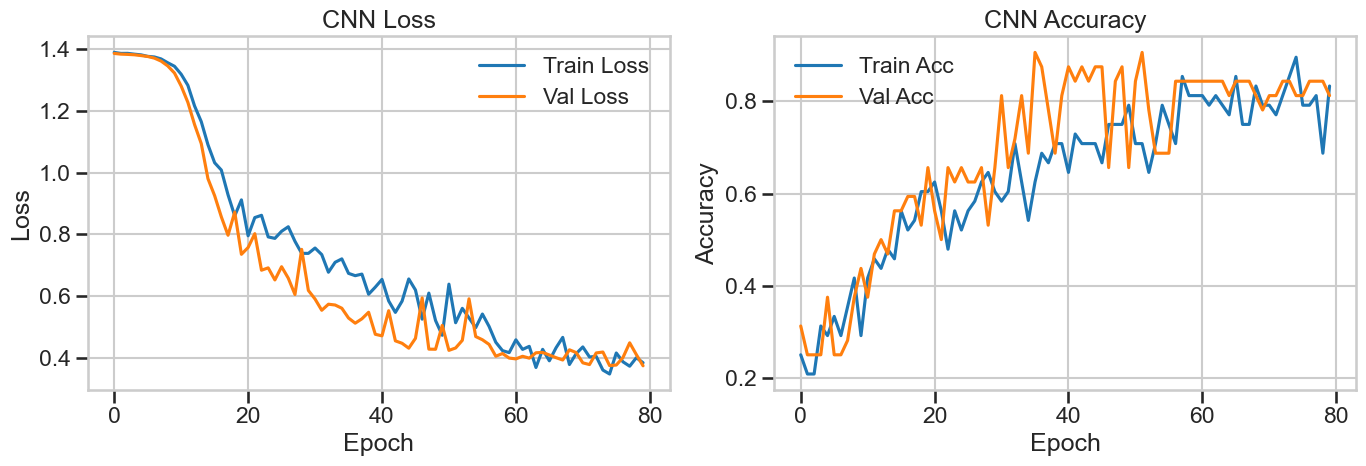

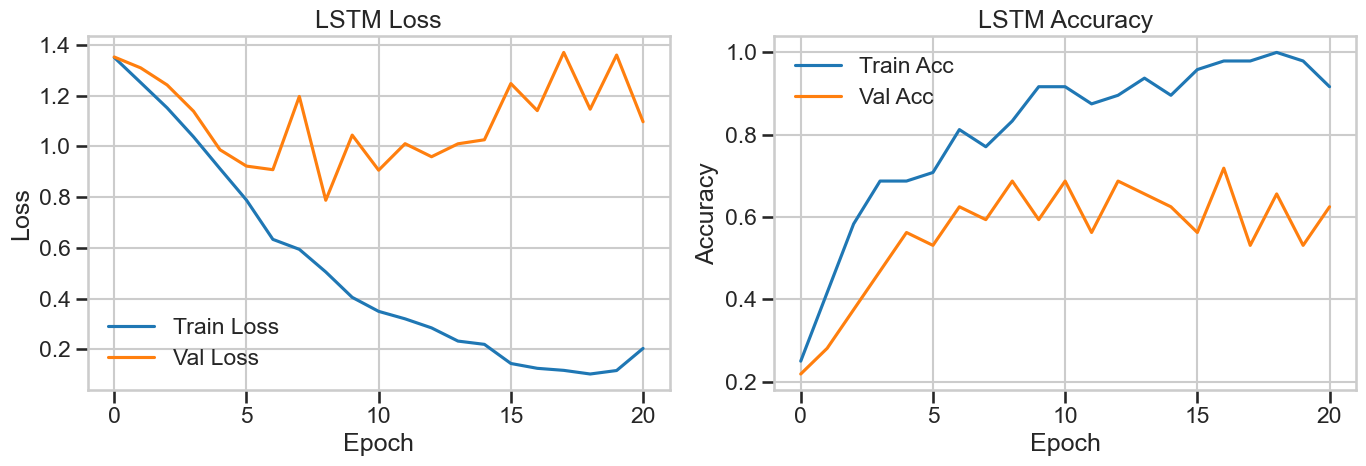

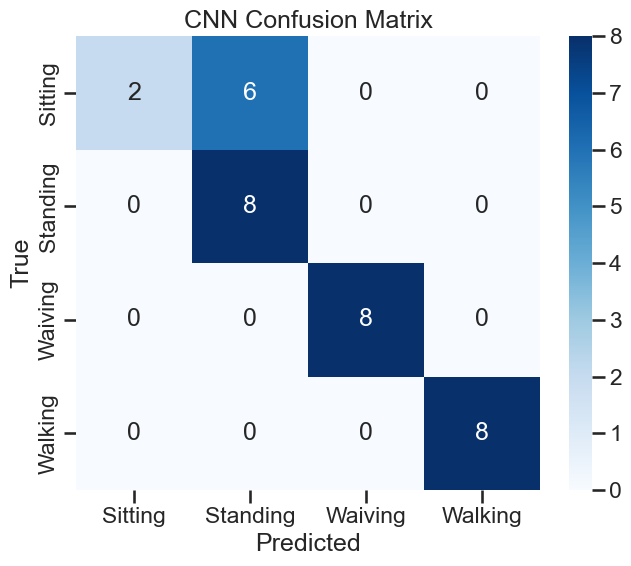


CNN Classification Report
              precision    recall  f1-score   support

     Sitting     1.0000    0.2500    0.4000         8
    Standing     0.5714    1.0000    0.7273         8
     Waiving     1.0000    1.0000    1.0000         8
     Walking     1.0000    1.0000    1.0000         8

    accuracy                         0.8125        32
   macro avg     0.8929    0.8125    0.7818        32
weighted avg     0.8929    0.8125    0.7818        32



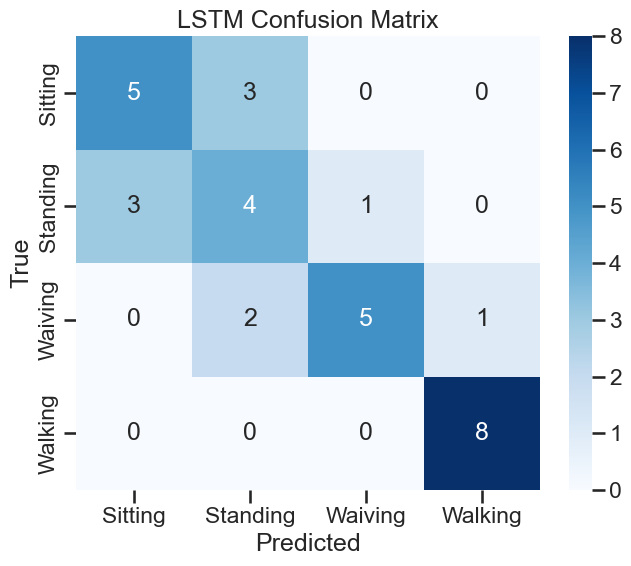


LSTM Classification Report
              precision    recall  f1-score   support

     Sitting     0.6250    0.6250    0.6250         8
    Standing     0.4444    0.5000    0.4706         8
     Waiving     0.8333    0.6250    0.7143         8
     Walking     0.8889    1.0000    0.9412         8

    accuracy                         0.6875        32
   macro avg     0.6979    0.6875    0.6878        32
weighted avg     0.6979    0.6875    0.6878        32


Model Report (sorted by Test Accuracy):


,Model,Test Accuracy,Macro F1,Weighted F1
0,CNN,0.8125,0.7818,0.7818
1,LSTM,0.6875,0.6878,0.6878


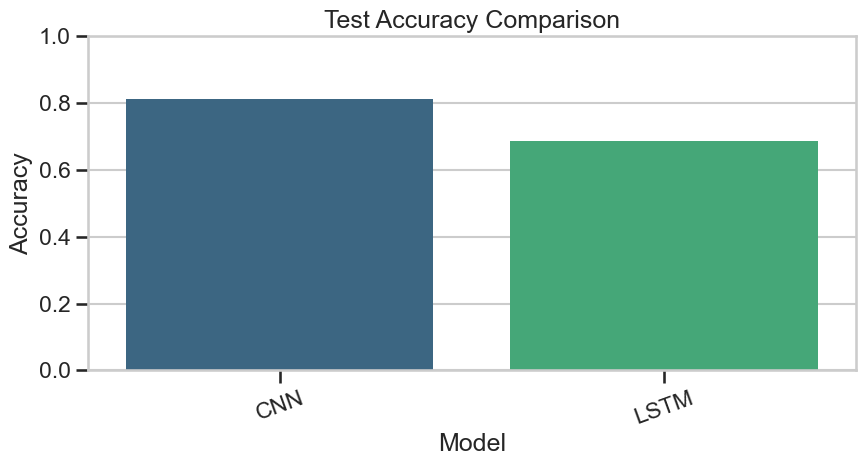

Best model: CNN | Accuracy=0.8125, Macro-F1=0.7818, Weighted-F1=0.7818


In [32]:
from sklearn.metrics import f1_score, accuracy_score


def plot_history(history, title_prefix="Model"):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(h["loss"], label="Train Loss")
    axes[0].plot(h["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title_prefix} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(h["accuracy"], label="Train Acc")
    axes[1].plot(h["val_accuracy"], label="Val Acc")
    axes[1].set_title(f"{title_prefix} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_classifier(model, x_test, y_test, labels, title="Model", show_cm=True):
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    if show_cm:
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(labels)))
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{title} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

        print(f"\n{title} Classification Report")
        print(classification_report(y_test, y_pred, target_names=labels, digits=4))

    return {
        "Model": title,
        "Test Accuracy": acc,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
    }


labels = EXPECTED_ACTIVITIES

# Plot training curves for all models
for name, hist in ablation_histories.items():
    plot_history(hist, name)

# Build report
ablation_rows = []
for name, model in ablation_models.items():
    if name == "CNN":
        row = evaluate_classifier(model, x_test_cnn, y_test, labels, title=name, show_cm=True)
    else:
        row = evaluate_classifier(model, x_test_lstm, y_test, labels, title=name, show_cm=True)
    ablation_rows.append(row)

ablation_report = pd.DataFrame(ablation_rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

print("\nModel Report (sorted by Test Accuracy):")
display(ablation_report.style.format({
    "Test Accuracy": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
}))

plt.figure(figsize=(9, 5))
sns.barplot(data=ablation_report, x="Model", y="Test Accuracy", palette="viridis")
plt.ylim(0, 1)
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_row = ablation_report.iloc[0]
print(
    f"Best model: {best_row['Model']} | "
    f"Accuracy={best_row['Test Accuracy']:.4f}, "
    f"Macro-F1={best_row['Macro F1']:.4f}, "
    f"Weighted-F1={best_row['Weighted F1']:.4f}"
)

## Social Behaviour Classification (Research Data)

This section applies the same end-to-end pipeline to `Research Data/Social Behaviour/2 People` using class folders under that directory.

In [33]:
SOCIAL_ROOT = Path.cwd() / "Research Data" / "Social Behaviour" / "2 People"
SOCIAL_CLASS_MAP = {
    "Approaching": "Approaching",
    "Sitting": "Sitting",
    "Splitting": "Splitting",
    "Standing": "Standing",
    "Walking_togather": "Walking_together",
}


def scan_social_behaviour_data(root: Path, class_map: dict[str, str]) -> pd.DataFrame:
    rows = []
    for folder_name, label in class_map.items():
        class_dir = root / folder_name
        if not class_dir.exists():
            print(f"Warning: class folder missing: {class_dir}")
            continue

        csv_files = sorted(class_dir.rglob("range_doppler.csv"))
        if len(csv_files) == 0:
            print(f"Warning: no range_doppler.csv found in {class_dir}")
            continue

        for csv_path in csv_files:
            df = read_longform(csv_path)
            rows.append(
                {
                    "activity": label,
                    "sample_name": csv_path.parent.name,
                    "csv_path": csv_path,
                    "rd_points": len(df),
                    "n_frames": int(df["frame_number"].nunique()),
                }
            )

    meta = pd.DataFrame(rows)
    if meta.empty:
        raise RuntimeError(f"No valid social behaviour samples found in: {root}")

    return meta.sort_values(["activity", "sample_name"]).reset_index(drop=True)


def split_social_by_sample(meta: pd.DataFrame) -> pd.DataFrame:
    out = meta.copy()
    out["split"] = ""

    for activity, g in out.groupby("activity"):
        g_sorted = g.sort_values(["sample_name"])
        idx = g_sorted.index.to_list()

        if len(idx) < 5:
            print(
                f"Warning: {activity} has {len(idx)} samples; using best possible split "
                "with target 3 train / 2 test when available."
            )

        # Target policy: first 3 train, next 2 test (for first 5 samples).
        train_idx = idx[:3]
        test_idx = idx[3:5]
        extra_idx = idx[5:]

        # For classes with >5 samples, keep extras in train to avoid unlabeled rows.
        train_idx = train_idx + extra_idx

        # Fallback for classes with fewer than 5 samples.
        if len(test_idx) == 0 and len(idx) > 1:
            split_point = max(1, len(idx) - 1)
            train_idx = idx[:split_point]
            test_idx = idx[split_point:]

        out.loc[train_idx, "split"] = "train"
        out.loc[test_idx, "split"] = "test"

    if (out["split"] == "").any():
        raise RuntimeError("Social split assignment failed for some samples")

    return out


if not SOCIAL_ROOT.exists():
    raise FileNotFoundError(f"Social behaviour root not found: {SOCIAL_ROOT}")

social_meta = scan_social_behaviour_data(SOCIAL_ROOT, SOCIAL_CLASS_MAP)
social_split_meta = split_social_by_sample(social_meta)

social_class_list = sorted(social_split_meta["activity"].unique())
social_class_to_id = {a: i for i, a in enumerate(social_class_list)}

social_view = social_split_meta.copy()
social_view["Target_Class_ID"] = social_view["activity"].map(social_class_to_id)
social_view = social_view.rename(
    columns={
        "activity": "Activity",
        "sample_name": "Sample",
        "n_frames": "Frames",
        "rd_points": "RD_Points",
        "split": "Split",
    }
)
social_view = social_view[["Activity", "Sample", "Frames", "RD_Points", "Split", "Target_Class_ID"]]

display(social_view)
print("\nSocial behaviour samples per class and split:")
print(social_split_meta.groupby(["activity", "split"]).size().unstack(fill_value=0))

,Activity,Sample,Frames,RD_Points,Split,Target_Class_ID
0,Approaching,1m,36,147456,train,0
1,Approaching,2m,63,516096,train,0
2,Approaching,3m,0,0,train,0
3,Approaching,radar_data_20251209_173331,35,286720,test,0
4,Approaching,radar_data_20251209_173758,25,102400,test,0
5,Approaching,radar_data_20251209_174007,0,0,train,0
6,Sitting,1m,17,139264,train,1
7,Sitting,2m,32,131072,train,1
8,Sitting,3m,19,155648,train,1
9,Sitting,radar_data_20251209_181620,26,212992,test,1



Social behaviour samples per class and split:
split             test  train
activity                     
Approaching          2      4
Sitting              2      3
Splitting            2      3
Standing             2      3
Walking_together     2      3


In [34]:
social_cnn_x, social_lstm_x, social_y = [], [], []
social_sample_trace = []
social_skipped = []

for _, row in social_split_meta.iterrows():
    df = read_longform(Path(row["csv_path"]))

    # Skip samples that contain no valid RD points after numeric cleaning.
    if df.empty:
        social_skipped.append((row["activity"], row["sample_name"], "empty dataframe"))
        continue

    cube = dataframe_to_cube(df)

    # Guard against malformed samples that produce zero temporal frames.
    if cube.size == 0 or cube.shape[0] == 0:
        social_skipped.append((row["activity"], row["sample_name"], "empty cube"))
        continue

    cube = filter_anomalous_cube(cube)
    rd_frames = np.stack([playback_like_process_frame(f, out_hw=SPATIAL_SIZE) for f in cube], axis=0)

    spec_td = rd_frames.sum(axis=1)
    spec_td = normalize_spectrogram(spec_td)
    spec_td = fix_sequence_len(spec_td, SEQ_LEN)
    windows = make_windows(spec_td, WINDOW_LEN, WINDOWS_PER_SAMPLE)

    for w in windows:
        cnn_img = resize_2d(w, out_hw=SPATIAL_SIZE)[..., None]
        lstm_seq = w

        social_cnn_x.append(cnn_img.astype(np.float32))
        social_lstm_x.append(lstm_seq.astype(np.float32))
        social_y.append(social_class_to_id[row["activity"]])
        social_sample_trace.append(row["split"] )

if len(social_cnn_x) == 0:
    raise RuntimeError("No valid social behaviour windows were generated after filtering.")

social_cnn_x = np.array(social_cnn_x, dtype=np.float32)
social_lstm_x = np.array(social_lstm_x, dtype=np.float32)
social_y = np.array(social_y, dtype=np.int32)
social_sample_trace = np.array(social_sample_trace)

social_is_train = (social_sample_trace == "train")
social_is_test = (social_sample_trace == "test")

social_x_train_cnn, social_x_test_cnn = social_cnn_x[social_is_train], social_cnn_x[social_is_test]
social_x_train_lstm, social_x_test_lstm = social_lstm_x[social_is_train], social_lstm_x[social_is_test]
social_y_train, social_y_test = social_y[social_is_train], social_y[social_is_test]

if len(social_y_test) == 0:
    raise RuntimeError("No test windows available for social behaviour evaluation.")

print("Social CNN train shape:", social_x_train_cnn.shape, "test:", social_x_test_cnn.shape)
print("Social LSTM train shape:", social_x_train_lstm.shape, "test:", social_x_test_lstm.shape)
print("Social y train/test:", social_y_train.shape, social_y_test.shape)

print("\nSocial class balance (train windows):")
print(pd.Series(social_y_train).map({v: k for k, v in social_class_to_id.items()}).value_counts())
print("\nSocial class balance (test windows):")
print(pd.Series(social_y_test).map({v: k for k, v in social_class_to_id.items()}).value_counts())

if social_skipped:
    print("\nSkipped social samples due to invalid/empty data:")
    for activity, sample_name, reason in social_skipped:
        print(f"- {activity} | {sample_name} | {reason}")

Social CNN train shape: (56, 64, 64, 1) test: (40, 64, 64, 1)
Social LSTM train shape: (56, 32, 64) test: (40, 32, 64)
Social y train/test: (56,) (40,)

Social class balance (train windows):
Sitting             12
Splitting           12
Standing            12
Walking_together    12
Approaching          8
Name: count, dtype: int64

Social class balance (test windows):
Approaching         8
Sitting             8
Splitting           8
Standing            8
Walking_together    8
Name: count, dtype: int64

Skipped social samples due to invalid/empty data:
- Approaching | 3m | empty dataframe
- Approaching | radar_data_20251209_174007 | empty dataframe



=== Training CNN ===
Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2031 - loss: 1.6196 - val_accuracy: 0.2250 - val_loss: 1.6080 - learning_rate: 0.0010
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2203 - loss: 1.6145 - val_accuracy: 0.2500 - val_loss: 1.6075 - learning_rate: 0.0010
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1807 - loss: 1.6115 - val_accuracy: 0.2500 - val_loss: 1.6072 - learning_rate: 0.0010
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3628 - loss: 1.5991 - val_accuracy: 0.2500 - val_loss: 1.6081 - learning_rate: 0.0010
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3631 - loss: 1.5934 - val_accuracy: 0.2750 - val_loss: 1.6119 - learning_rate: 0.0010
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3853 - loss: 1.5739 - val_accuracy: 0.3000 - val_loss: 1.6223 - learning_rate: 0.0010
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2459 - loss: 1.5496 -

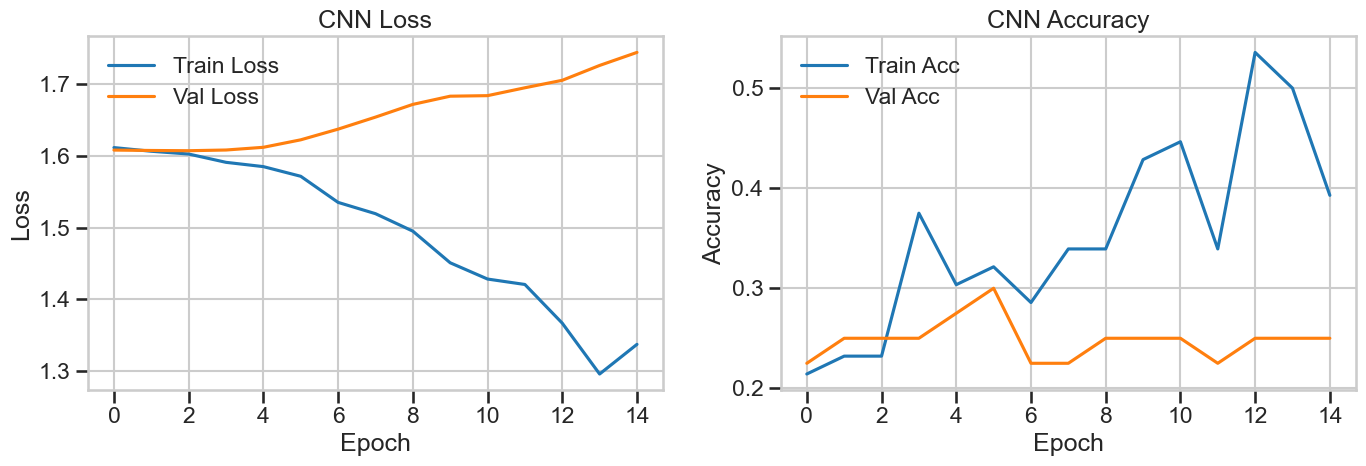

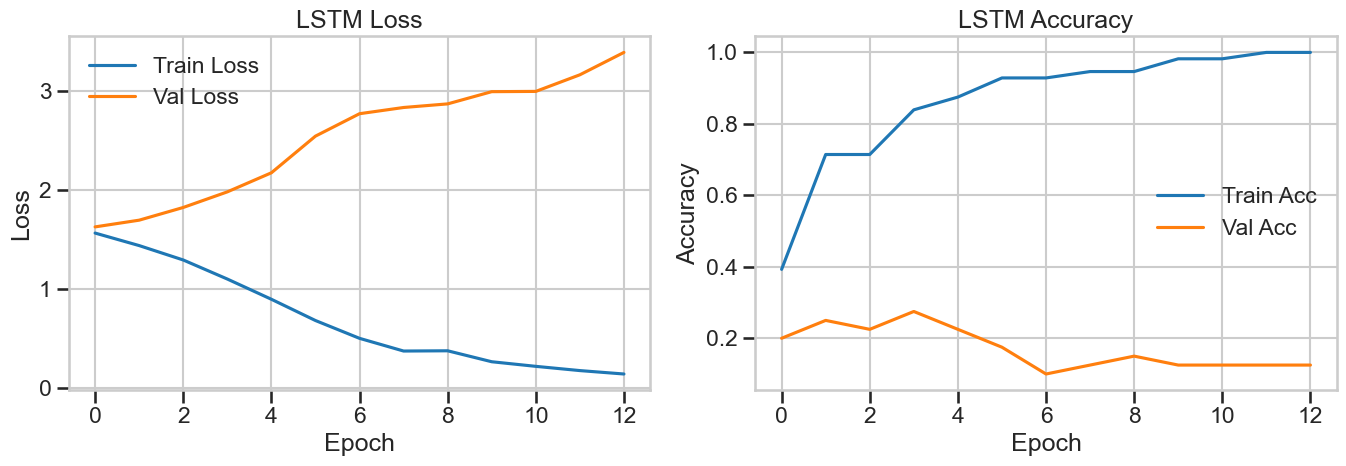

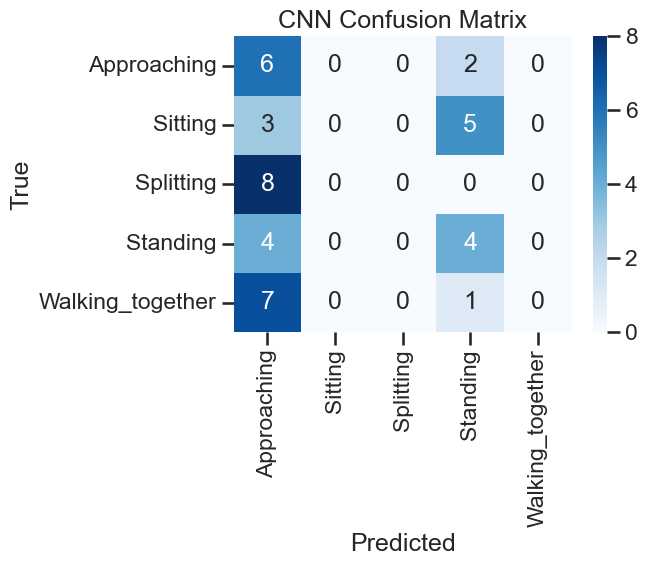


CNN Classification Report
                  precision    recall  f1-score   support

     Approaching     0.2143    0.7500    0.3333         8
         Sitting     0.0000    0.0000    0.0000         8
       Splitting     0.0000    0.0000    0.0000         8
        Standing     0.3333    0.5000    0.4000         8
Walking_together     0.0000    0.0000    0.0000         8

        accuracy                         0.2500        40
       macro avg     0.1095    0.2500    0.1467        40
    weighted avg     0.1095    0.2500    0.1467        40



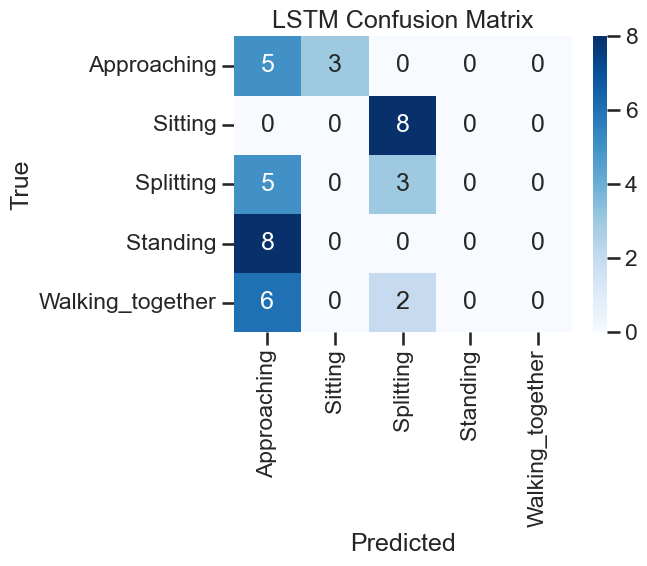


LSTM Classification Report
                  precision    recall  f1-score   support

     Approaching     0.2083    0.6250    0.3125         8
         Sitting     0.0000    0.0000    0.0000         8
       Splitting     0.2308    0.3750    0.2857         8
        Standing     0.0000    0.0000    0.0000         8
Walking_together     0.0000    0.0000    0.0000         8

        accuracy                         0.2000        40
       macro avg     0.0878    0.2000    0.1196        40
    weighted avg     0.0878    0.2000    0.1196        40


Model Report (sorted by Test Accuracy):


,Model,Test Accuracy,Macro F1,Weighted F1
0,CNN,0.2500,0.1467,0.1467
1,LSTM,0.2000,0.1196,0.1196


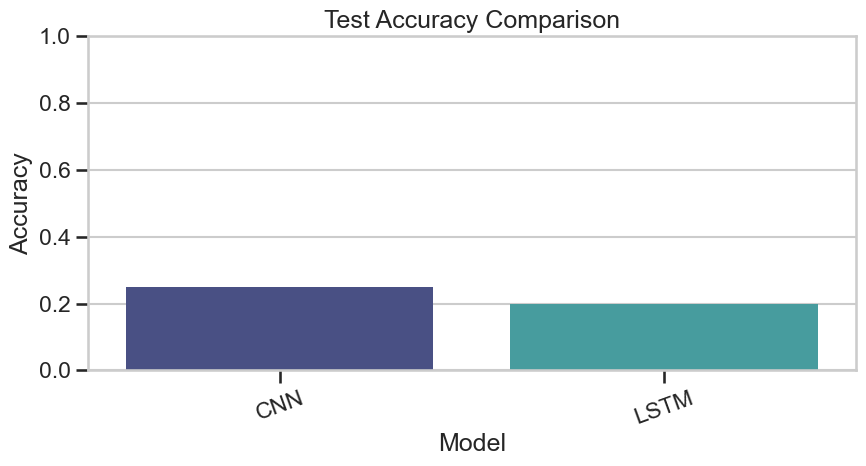

Best social model: CNN | Accuracy=0.2500, Macro-F1=0.1467, Weighted-F1=0.1467


In [37]:
social_n_classes = len(social_class_list)

social_models = {
    "CNN": build_cnn_baseline(social_x_train_cnn.shape[1:], social_n_classes),
    "LSTM": build_lstm_baseline(social_x_train_lstm.shape[1:], social_n_classes),
}

social_histories = {}
for name, model in social_models.items():
    print(f"\n=== Training {name} ===")
    if name == "CNN":
        hist = train_model(
            model, social_x_train_cnn, social_y_train, social_x_test_cnn, social_y_test, epochs=80, batch_size=8
        )
    else:
        hist = train_model(
            model, social_x_train_lstm, social_y_train, social_x_test_lstm, social_y_test, epochs=80, batch_size=8
        )
    social_histories[name] = hist

for name, hist in social_histories.items():
    plot_history(hist, f"{name}")

social_rows = []
for name, model in social_models.items():
    if name == "CNN":
        row = evaluate_classifier(
            model,
            social_x_test_cnn,
            social_y_test,
            social_class_list,
            title=f"{name}",
            show_cm=True,
        )
    else:
        row = evaluate_classifier(
            model,
            social_x_test_lstm,
            social_y_test,
            social_class_list,
            title=f"{name}",
            show_cm=True,
        )
    social_rows.append(row)

social_report = pd.DataFrame(social_rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

print("\nModel Report (sorted by Test Accuracy):")
display(social_report.style.format({
    "Test Accuracy": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
}))

plt.figure(figsize=(9, 5))
sns.barplot(data=social_report, x="Model", y="Test Accuracy", palette="mako")
plt.ylim(0, 1)
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

social_best = social_report.iloc[0]
print(
    f"Best social model: {social_best['Model']} | "
    f"Accuracy={social_best['Test Accuracy']:.4f}, "
    f"Macro-F1={social_best['Macro F1']:.4f}, "
    f"Weighted-F1={social_best['Weighted F1']:.4f}"
)